<a href="https://colab.research.google.com/github/pinkprincess536/eeg/blob/main/eeg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mne numpy pandas matplotlib

In [2]:
import mne
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

BASE_DIR = "/content/drive/MyDrive/EEG_PROJECT"

os.makedirs(BASE_DIR, exist_ok=True)

print("Created:", BASE_DIR)

Created: /content/drive/MyDrive/EEG_PROJECT


In [5]:
!pip install -q mne

import os
import subprocess

BASE_DIR = "/content/drive/MyDrive/EEG_PROJECT"

patients = {
    "chb01": [
        # Seizure
        "chb01_15.edf",
        "chb01_15.edf.seizures",
        "chb01_16.edf",
        "chb01_16.edf.seizures",
        "chb01_18.edf",
        "chb01_18.edf.seizures",
        "chb01_21.edf",
        "chb01_21.edf.seizures",

        # Non-seizure
        "chb01_17.edf",
        "chb01_19.edf",
        "chb01_20.edf"
    ],

    "chb02": [
        # Seizure
        "chb02_16.edf",
        "chb02_16.edf.seizures",
        "chb02_16+.edf",
        "chb02_16+.edf.seizures",
        "chb02_19.edf",
        "chb02_19.edf.seizures",

        # Non-seizure
        "chb02_10.edf",
        "chb02_11.edf",
        "chb02_12.edf",
        "chb02_13.edf"
    ],

    "chb03": [
        # Seizure
        "chb03_01.edf",
        "chb03_01.edf.seizures",
        "chb03_02.edf",
        "chb03_02.edf.seizures",
        "chb03_03.edf",
        "chb03_03.edf.seizures",
        "chb03_04.edf",
        "chb03_04.edf.seizures",

        # Non-seizure
        "chb03_05.edf",
        "chb03_06.edf",
        "chb03_07.edf"
    ]
}

for patient, files in patients.items():

    patient_dir = os.path.join(BASE_DIR, patient)
    os.makedirs(patient_dir, exist_ok=True)

    base_url = f"https://physionet.org/files/chbmit/1.0.0/{patient}/"

    print(f"\nDownloading {patient}...")

    for file in files:

        output_path = os.path.join(patient_dir, file)

        # Skip already-downloaded files
        if os.path.exists(output_path):
            print(f"Skipping {file} (already exists)")
            continue

        url = base_url + file

        print(f"Downloading {file}...")

        subprocess.run([
            "wget",
            "-q",
            "-O",
            output_path,
            url
        ])

print("\nAll downloads completed.")


Skipping chb01_15.edf (already exists)
Skipping chb01_15.edf.seizures (already exists)
Skipping chb01_16.edf (already exists)
Skipping chb01_16.edf.seizures (already exists)
Skipping chb01_18.edf (already exists)
Skipping chb01_18.edf.seizures (already exists)
Skipping chb01_21.edf (already exists)
Skipping chb01_21.edf.seizures (already exists)
Skipping chb01_17.edf (already exists)
Skipping chb01_19.edf (already exists)
Skipping chb01_20.edf (already exists)

Skipping chb02_16.edf (already exists)
Skipping chb02_16.edf.seizures (already exists)
Skipping chb02_16+.edf (already exists)
Skipping chb02_16+.edf.seizures (already exists)
Skipping chb02_19.edf (already exists)
Skipping chb02_19.edf.seizures (already exists)
Skipping chb02_10.edf (already exists)
Skipping chb02_11.edf (already exists)
Skipping chb02_12.edf (already exists)
Skipping chb02_13.edf (already exists)

Skipping chb03_01.edf (already exists)
Skipping chb03_01.edf.seizures (already exists)
Skipping chb03_02.edf (alr

In [6]:
!ls "/content/drive/MyDrive/EEG_PROJECT"

chb01		   chb01-summary.txt.1	chb02-summary.txt  chb03-summary.txt
chb01-summary.txt  chb02		chb03


In [7]:
!find "/content/drive/MyDrive/EEG_PROJECT" -type f | wc -l


36


In [8]:
!ls "/content/drive/MyDrive/EEG_PROJECT/chb01"


chb01_15.edf	       chb01_17.edf	      chb01_20.edf
chb01_15.edf.seizures  chb01_18.edf	      chb01_21.edf
chb01_16.edf	       chb01_18.edf.seizures  chb01_21.edf.seizures
chb01_16.edf.seizures  chb01_19.edf


In [9]:
import mne
import matplotlib.pyplot as plt

In [10]:
seizure_file = "/content/drive/MyDrive/EEG_PROJECT/chb01/chb01_15.edf.seizures"

with open(seizure_file, "rb") as f:
    content = f.read()

print(content[:500])

b'\x00X\x17\xfc## time resolution: 256\x00\x00\xec\xff\xff\xff\xff\x01\x00\x00\xec\x06\x00\x00\xc4\x00\x80\x00\xec\x00\x00\x00(\x00\x84\x00\x00'


In [11]:
import mne

file_path = "/content/drive/MyDrive/EEG_PROJECT/chb01/chb01_15.edf"

raw = mne.io.read_raw_edf(file_path, preload=False)

print(raw.info
      )

Extracting EDF parameters from /content/drive/MyDrive/EEG_PROJECT/chb01/chb01_15.edf...
Setting channel info structure...
Creating raw.info structure...
<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-07 01:44:44 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>


/tmp/ipykernel_13649/1749232387.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=False)


Using matplotlib as 2D backend.


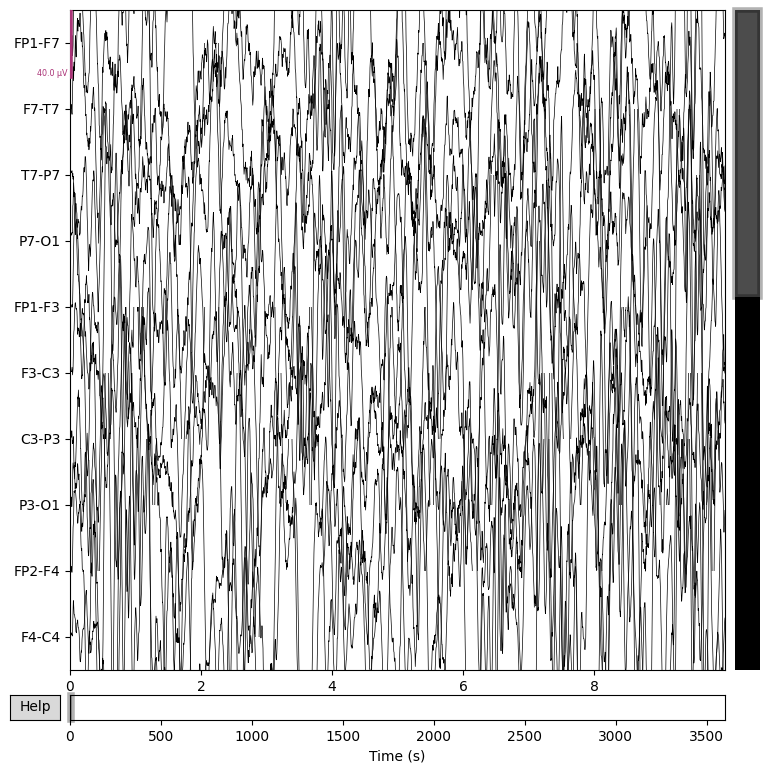

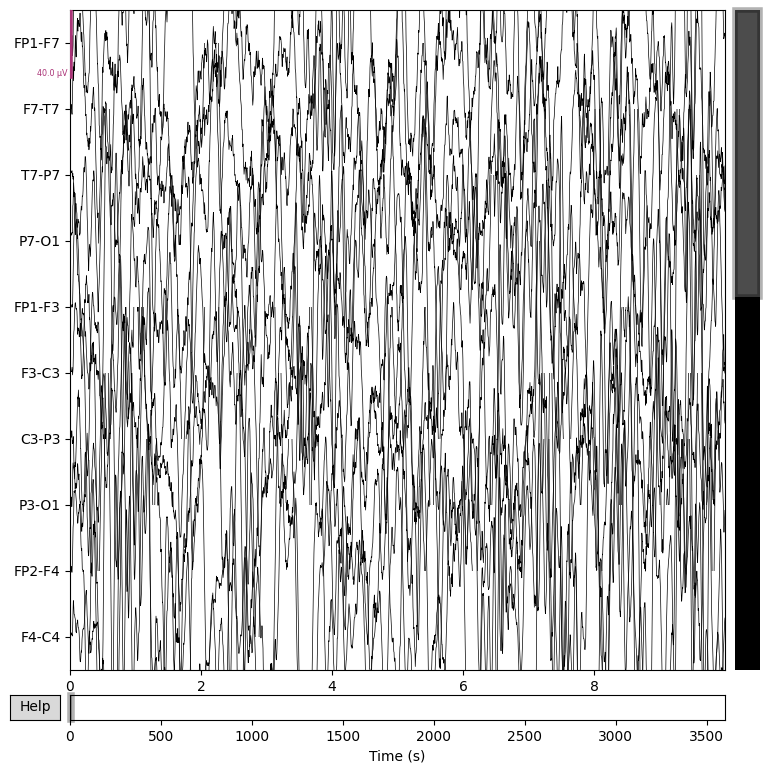

In [12]:
raw.plot(duration=10, n_channels=10)

In [13]:
duration_sec = raw.times[-1]

print("Seconds:", duration_sec)
print("Minutes:", duration_sec / 60)


Seconds: 3599.99609375
Minutes: 59.999934895833334


In [14]:
!wget -P "/content/drive/MyDrive/EEG_PROJECT" \
https://physionet.org/files/chbmit/1.0.0/chb01/chb01-summary.txt

--2026-05-16 09:09:17--  https://physionet.org/files/chbmit/1.0.0/chb01/chb01-summary.txt
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5355 (5.2K) [text/plain]
Saving to: ‘/content/drive/MyDrive/EEG_PROJECT/chb01-summary.txt.2’

chb01-summary.txt.2 100%[===================>]   5.23K  --.-KB/s    in 0s      

2026-05-16 09:09:18 (458 MB/s) - ‘/content/drive/MyDrive/EEG_PROJECT/chb01-summary.txt.2’ saved [5355/5355]



In [15]:
summary_path = "/content/drive/MyDrive/EEG_PROJECT/chb01-summary.txt"

with open(summary_path, "r") as f:
    content = f.read()

print(content[:5000])


Data Sampling Rate: 256 Hz
*************************

Channels in EDF Files:
**********************
Channel 1: FP1-F7
Channel 2: F7-T7
Channel 3: T7-P7
Channel 4: P7-O1
Channel 5: FP1-F3
Channel 6: F3-C3
Channel 7: C3-P3
Channel 8: P3-O1
Channel 9: FP2-F4
Channel 10: F4-C4
Channel 11: C4-P4
Channel 12: P4-O2
Channel 13: FP2-F8
Channel 14: F8-T8
Channel 15: T8-P8
Channel 16: P8-O2
Channel 17: FZ-CZ
Channel 18: CZ-PZ
Channel 19: P7-T7
Channel 20: T7-FT9
Channel 21: FT9-FT10
Channel 22: FT10-T8
Channel 23: T8-P8

File Name: chb01_01.edf
File Start Time: 11:42:54
File End Time: 12:42:54
Number of Seizures in File: 0

File Name: chb01_02.edf
File Start Time: 12:42:57
File End Time: 13:42:57
Number of Seizures in File: 0

File Name: chb01_03.edf
File Start Time: 13:43:04
File End Time: 14:43:04
Number of Seizures in File: 1
Seizure Start Time: 2996 seconds
Seizure End Time: 3036 seconds

File Name: chb01_04.edf
File Start Time: 14:43:12
File End Time: 15:43:12
Number of Seizures in File: 1
S

In [16]:
!wget -P "/content/drive/MyDrive/EEG_PROJECT" \
https://physionet.org/files/chbmit/1.0.0/chb01/chb01-summary.txt

!wget -P "/content/drive/MyDrive/EEG_PROJECT" \
https://physionet.org/files/chbmit/1.0.0/chb02/chb02-summary.txt

!wget -P "/content/drive/MyDrive/EEG_PROJECT" \
https://physionet.org/files/chbmit/1.0.0/chb03/chb03-summary.txt

--2026-05-16 09:09:18--  https://physionet.org/files/chbmit/1.0.0/chb01/chb01-summary.txt
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5355 (5.2K) [text/plain]
Saving to: ‘/content/drive/MyDrive/EEG_PROJECT/chb01-summary.txt.3’

chb01-summary.txt.3 100%[===================>]   5.23K  --.-KB/s    in 0s      

2026-05-16 09:09:19 (409 MB/s) - ‘/content/drive/MyDrive/EEG_PROJECT/chb01-summary.txt.3’ saved [5355/5355]

--2026-05-16 09:09:19--  https://physionet.org/files/chbmit/1.0.0/chb02/chb02-summary.txt
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4471 (4.4K) [text/plain]
Saving to: ‘/content/drive/MyDrive/EEG_PROJECT/chb02-summary.txt.1’

chb02-summary.txt.1 100%[===================>]   4.37K  --.-KB/s    

In [17]:
!ls "/content/drive/MyDrive/EEG_PROJECT"

chb01		     chb01-summary.txt.3  chb03
chb01-summary.txt    chb02		  chb03-summary.txt
chb01-summary.txt.1  chb02-summary.txt	  chb03-summary.txt.1
chb01-summary.txt.2  chb02-summary.txt.1


In [18]:
import re

BASE_PATH = "/content/drive/MyDrive/EEG_PROJECT"

all_seizure_info = []

for patient, files in patients.items():

    summary_file = f"{BASE_PATH}/{patient}-summary.txt"

    with open(summary_file, "r") as f:
        content = f.read()

    for file_name in files:

        if file_name not in content:
            continue

        # Find section for this EDF
        pattern = rf"File Name: {re.escape(file_name)}(.*?)(?=File Name:|\Z)"

        match = re.search(pattern, content, re.S)

        if not match:
            continue

        section = match.group(1)

        seizure_starts = re.findall(
            r"Seizure Start Time:\s*(\d+)\s*seconds",
            section
        )

        seizure_ends = re.findall(
            r"Seizure End Time:\s*(\d+)\s*seconds",
            section
        )

        info = {
            "patient": patient,
            "file": file_name,
            "num_seizures": len(seizure_starts),
            "starts": seizure_starts,
            "ends": seizure_ends
        }

        all_seizure_info.append(info)

for item in all_seizure_info:
    print(item)

{'patient': 'chb01', 'file': 'chb01_15.edf', 'num_seizures': 1, 'starts': ['1732'], 'ends': ['1772']}
{'patient': 'chb01', 'file': 'chb01_16.edf', 'num_seizures': 1, 'starts': ['1015'], 'ends': ['1066']}
{'patient': 'chb01', 'file': 'chb01_18.edf', 'num_seizures': 1, 'starts': ['1720'], 'ends': ['1810']}
{'patient': 'chb01', 'file': 'chb01_21.edf', 'num_seizures': 1, 'starts': ['327'], 'ends': ['420']}
{'patient': 'chb01', 'file': 'chb01_17.edf', 'num_seizures': 0, 'starts': [], 'ends': []}
{'patient': 'chb01', 'file': 'chb01_19.edf', 'num_seizures': 0, 'starts': [], 'ends': []}
{'patient': 'chb01', 'file': 'chb01_20.edf', 'num_seizures': 0, 'starts': [], 'ends': []}
{'patient': 'chb02', 'file': 'chb02_16.edf', 'num_seizures': 1, 'starts': ['130'], 'ends': ['212']}
{'patient': 'chb02', 'file': 'chb02_16+.edf', 'num_seizures': 1, 'starts': ['2972'], 'ends': ['3053']}
{'patient': 'chb02', 'file': 'chb02_19.edf', 'num_seizures': 1, 'starts': ['3369'], 'ends': ['3378']}
{'patient': 'chb02'

In [19]:
import mne

file_path = "/content/drive/MyDrive/EEG_PROJECT/chb01/chb01_15.edf"

raw = mne.io.read_raw_edf(file_path, preload=True)

print(raw)

Extracting EDF parameters from /content/drive/MyDrive/EEG_PROJECT/chb01/chb01_15.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_13649/3981689647.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True)


<RawEDF | chb01_15.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>


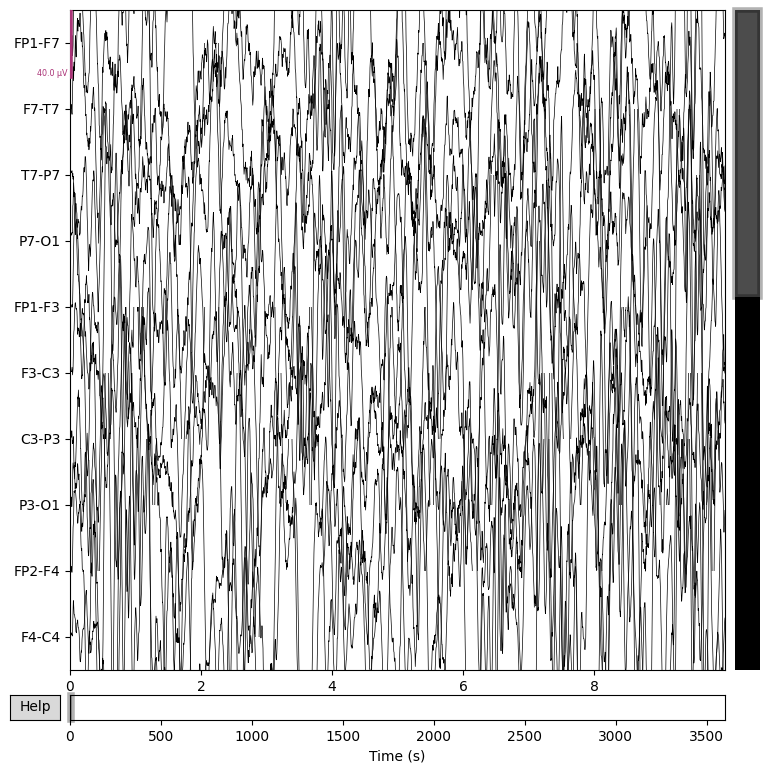

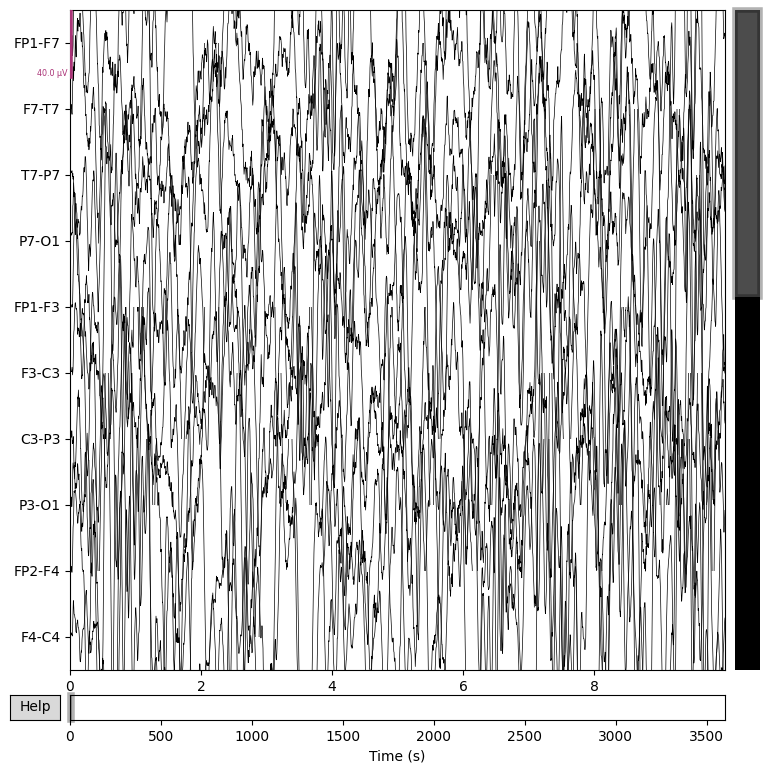

In [20]:
raw.plot(duration=10, n_channels=10)

In [21]:
!pip install mne

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
file_path = "/content/drive/MyDrive/EEG_PROJECT/chb01/chb01_15.edf"

raw = mne.io.read_raw_edf(file_path, preload=True)

print(raw)

Extracting EDF parameters from /content/drive/MyDrive/EEG_PROJECT/chb01/chb01_15.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_13649/2827085690.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True)


<RawEDF | chb01_15.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>


In [24]:
raw.filter(0.5, 40)

# Remove 60 Hz electrical interference
raw.notch_filter(freqs=60)

print("\nFiltering Complete")

# =========================================================
# STEP 3 — CONVERT EEG OBJECT TO NUMPY ARRAY
# =========================================================

signal = raw.get_data()

print("\nSignal Shape:")
print(signal.shape)

# Shape meaning:
# (channels, time_samples)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband e

In [26]:
import numpy as np
sfreq = raw.info['sfreq']

window_size_sec = 7

overlap = 0.5

# Convert seconds → samples
window_samples = int(window_size_sec * sfreq)

# Stride controls overlap movement
stride = int(window_samples * (1 - overlap))

print("\nWindow Parameters")
print("Sampling Frequency:", sfreq)
print("Window Samples:", window_samples)
print("Stride:", stride)

# =========================================================
# STEP 5 — GENERATE WINDOWS
# =========================================================

windows = []

total_samples = signal.shape[1]

for start in range(0, total_samples - window_samples, stride):

    end = start + window_samples

    # Extract window
    window = signal[:, start:end]

    windows.append(window)

windows = np.array(windows)

print("\nGenerated Windows Shape:")
print(windows.shape)

# Shape:
# (num_windows, channels, samples)

# =========================================================
# STEP 6 — LABEL WINDOWS
# =========================================================

# Seizure timestamps for chb01_15.edf
seizure_start = 1732
seizure_end = 1772

labels = []

for start in range(0, total_samples - window_samples, stride):

    # Convert sample index → seconds
    start_sec = start / sfreq
    end_sec = (start + window_samples) / sfreq

    # Check overlap with seizure interval
    if end_sec >= seizure_start and start_sec <= seizure_end:
        labels.append(1)
    else:
        labels.append(0)

labels = np.array(labels)

print("\nLabels Shape:")
print(labels.shape)

print("Total Seizure Windows:", np.sum(labels))
print("Total Non-Seizure Windows:", len(labels) - np.sum(labels))

# =========================================================
# FINAL DATASET
# =========================================================

X = windows
y = labels

print("\nFINAL DATASET")
print("X shape:", X.shape)
print("y shape:", y.shape)



Window Parameters
Sampling Frequency: 256.0
Window Samples: 1792
Stride: 896

Generated Windows Shape:
(1027, 23, 1792)

Labels Shape:
(1027,)
Total Seizure Windows: 14
Total Non-Seizure Windows: 1013

FINAL DATASET
X shape: (1027, 23, 1792)
y shape: (1027,)


In [27]:
unique, counts = np.unique(y, return_counts=True)

print(dict(zip(unique, counts)))


{np.int64(0): np.int64(1013), np.int64(1): np.int64(14)}


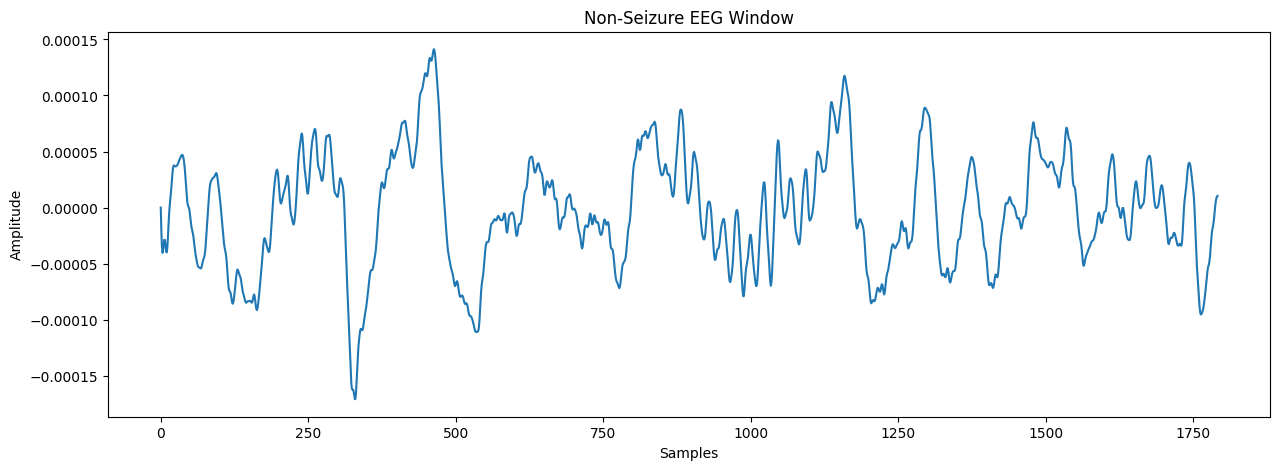

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(X[0][0])

plt.title("Non-Seizure EEG Window")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

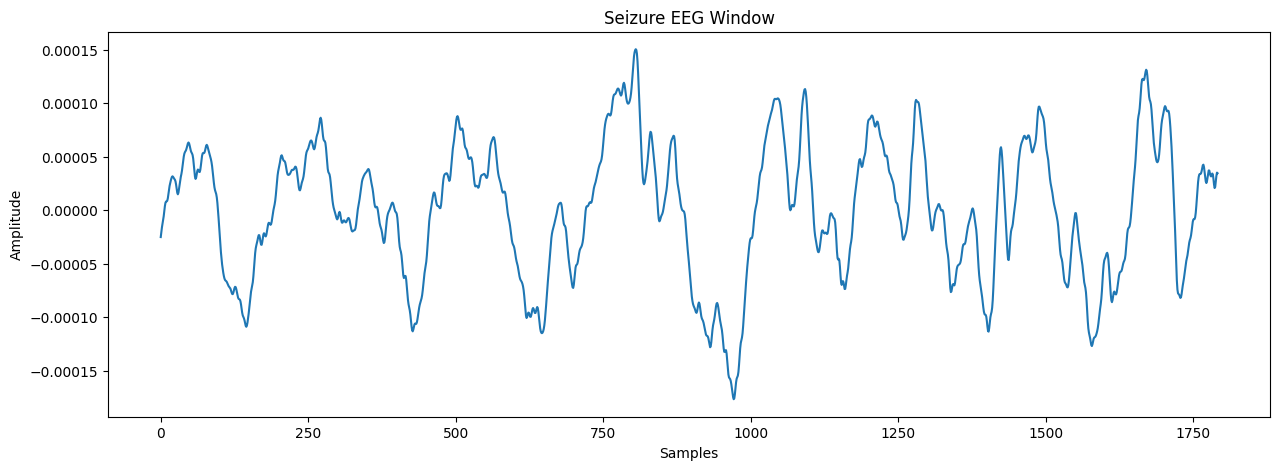

In [29]:
seizure_index = np.where(y == 1)[0][0]

plt.figure(figsize=(15,5))

plt.plot(X[seizure_index][0])

plt.title("Seizure EEG Window")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()